Loading all data and model objects...
  All data loaded.

Computing SHAP values for dashboard...
  SHAP done.

Building dashboard...


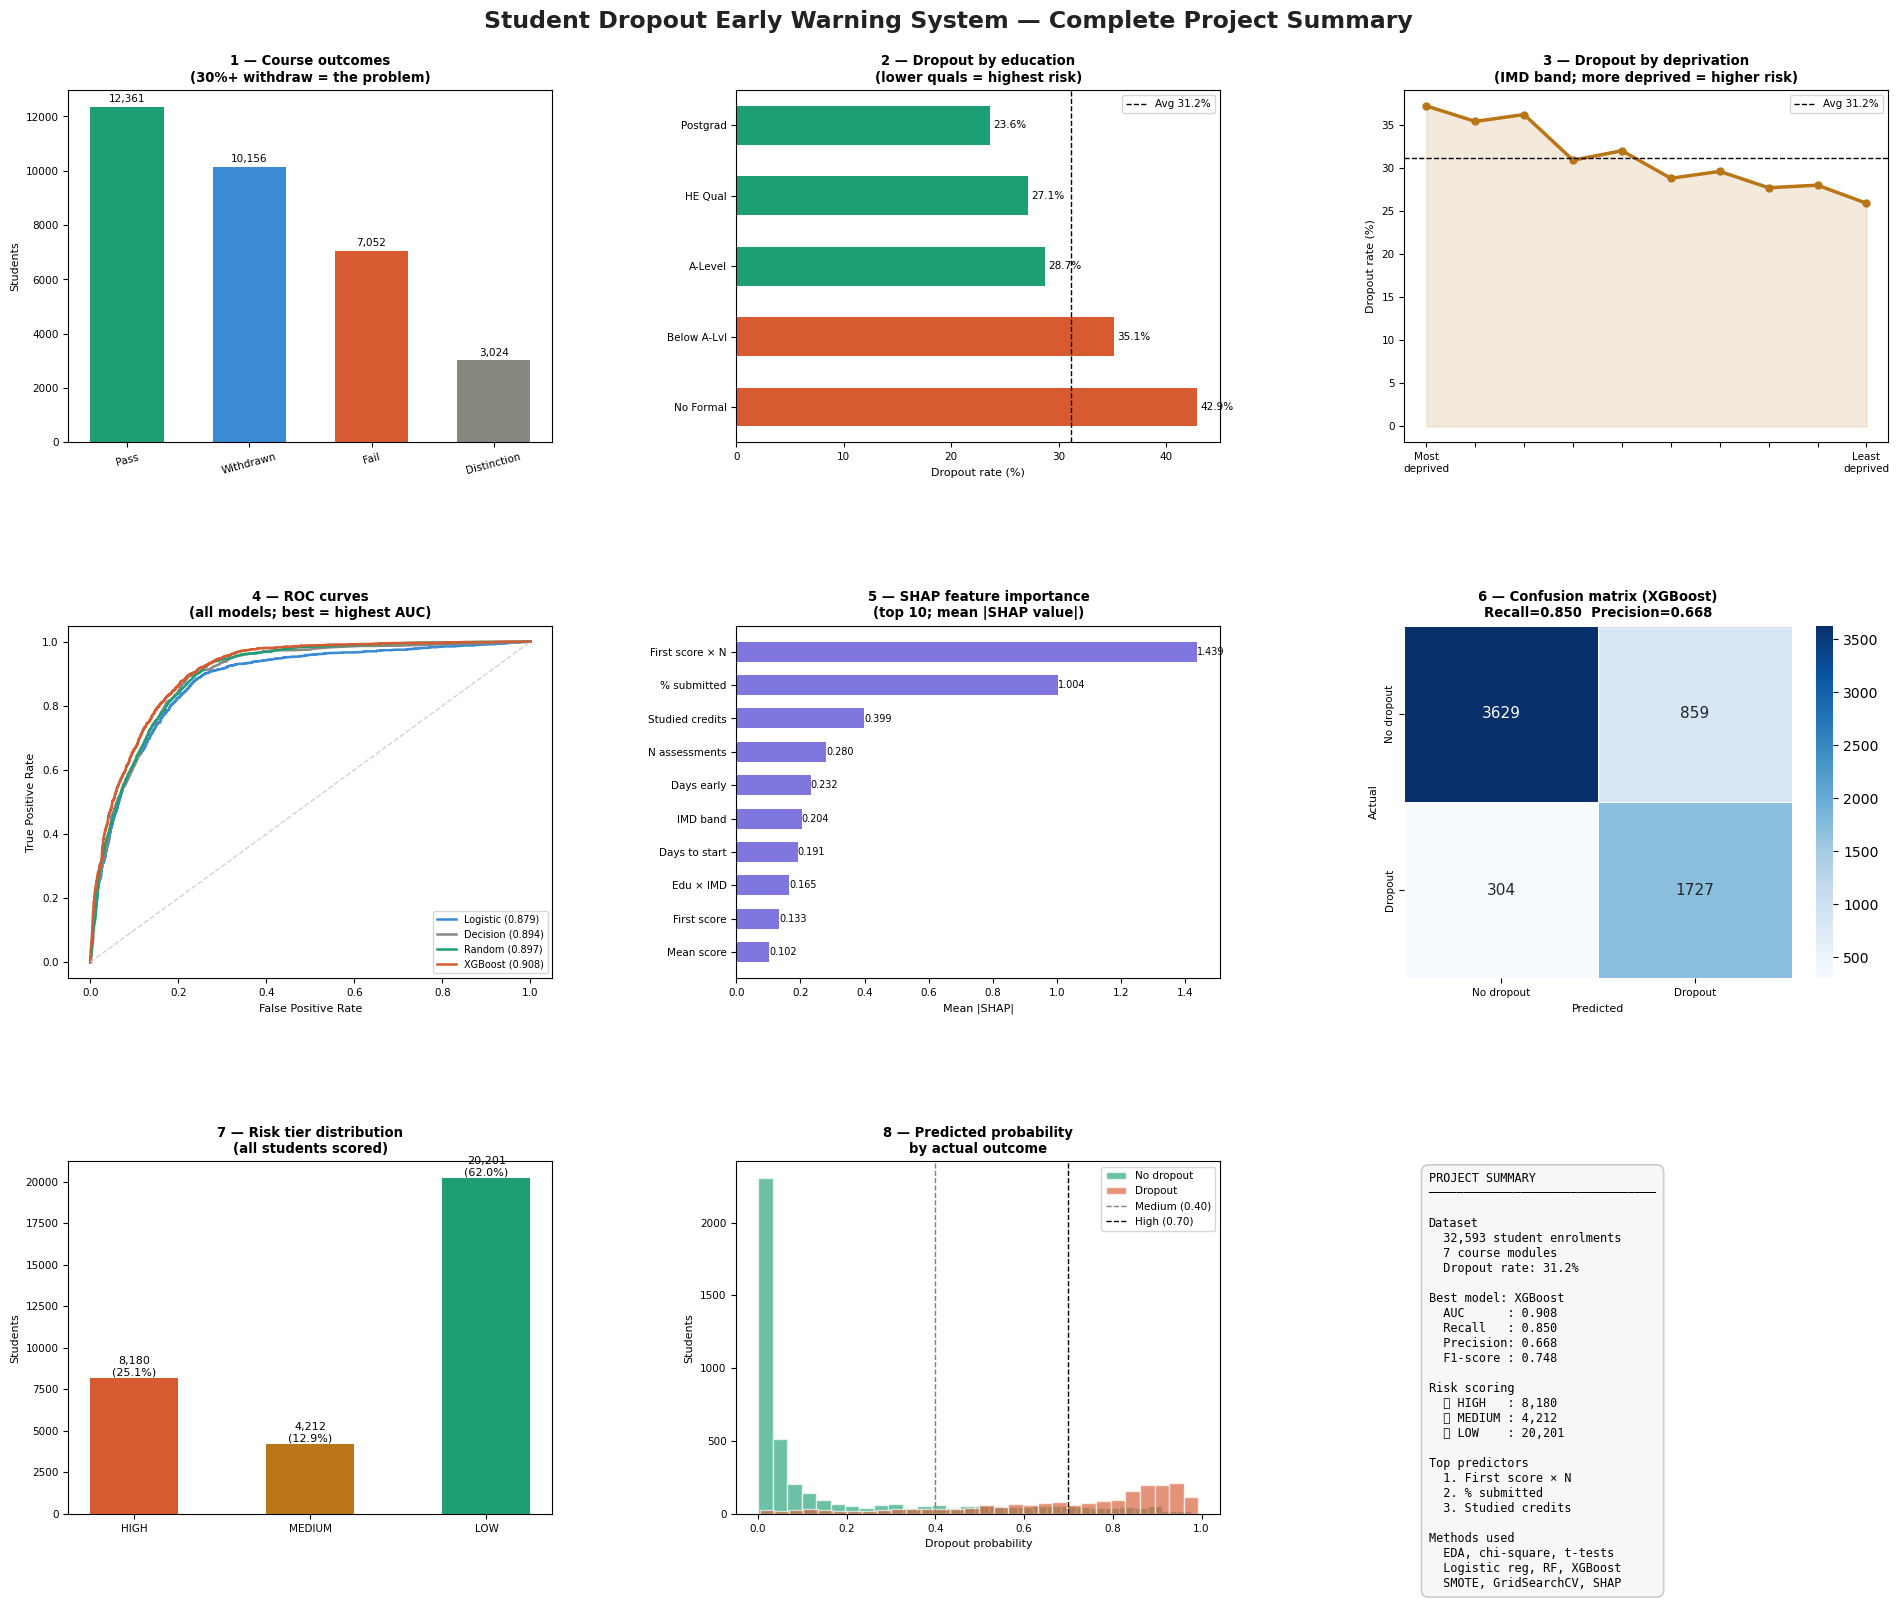

  ✅ Dashboard saved → ./outputs/phase5/block_c/phase5_dashboard.png

  ✅ Hi-res version saved → ./outputs/phase5/block_c/phase5_dashboard_hires.png


BLOCK C COMPLETE — Visualisation Dashboard

  9-panel dashboard covers:
    Row 1 — The problem  : outcomes, education, deprivation
    Row 2 — The model    : ROC, SHAP importance, confusion matrix
    Row 3 — The output   : risk tiers, probability dist., summary

  Files saved to: ./outputs/phase5/block_c/
    ✅ phase5_dashboard.png        (180 dpi — web/portfolio)
    ✅ phase5_dashboard_hires.png  (300 dpi — print/PDF)

─────────────────────────────────────────────────────────
Next → Run phase5_block_d_portfolio_packaging.py
─────────────────────────────────────────────────────────



<Figure size 640x480 with 0 Axes>

In [1]:
"""
=============================================================
Phase 5 — Block C: Visualisation Dashboard
=============================================================
Goal: Compile the best charts from all four phases into a
      single, portfolio-ready dashboard figure.

This is the chart you include in your:
  • GitHub README
  • LinkedIn project post
  • CV / portfolio PDF
  • Presentation slides

Design principles:
  • 3×3 grid — 9 panels, each telling one part of the story
  • Consistent colour palette throughout
  • Clear titles that a non-technical reader can follow
  • Self-contained — no prior context needed to understand it

Panel layout:
  Row 1 — The problem and the data
    [1] Outcome distribution        [2] Dropout by education    [3] IMD band dropout rate
  Row 2 — The model
    [4] ROC curves (all models)     [5] Feature importance      [6] Confusion matrix (best)
  Row 3 — The output
    [7] Risk tier distribution      [8] Prob. histogram         [9] Key metrics summary
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ── Config ────────────────────────────────────────────────────
DATA_PATH    = './data/'
BLOCK_A_PATH = './outputs/phase4/block_a/'
BLOCK_D_PATH = './outputs/phase4/block_d/'
BLOCK_E_PATH = './outputs/phase4/block_e/'
BLOCK_F_PATH = './outputs/phase4/block_f/'
OUTPUT_PATH  = './outputs/phase5/block_c/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
MODEL_COLORS = {
    'Logistic Regression': COLORS['blue'],
    'Decision Tree':       COLORS['gray'],
    'Random Forest':       COLORS['teal'],
    'XGBoost':             COLORS['coral'],
}
TIER_COLORS = {
    'HIGH':   COLORS['coral'],
    'MEDIUM': COLORS['amber'],
    'LOW':    COLORS['teal'],
}

# ── Load all data ─────────────────────────────────────────────
print("Loading all data and model objects...")

si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

with open(os.path.join(BLOCK_A_PATH, 'block_a_objects.pkl'), 'rb') as f:
    a_obj = pickle.load(f)
with open(os.path.join(BLOCK_D_PATH, 'block_d_objects.pkl'), 'rb') as f:
    d_obj = pickle.load(f)

metrics_df      = d_obj['metrics_df']
best_model_name = d_obj['best_model_name']
best_model      = d_obj['best_model']
best_threshold  = d_obj['best_threshold']
all_probas      = d_obj['all_probas']
all_models      = d_obj['all_models']
X_test          = d_obj['X_test']
y_test          = d_obj['y_test']
FEATURES        = d_obj['feature_names']

risk_table = pd.read_csv(
    os.path.join(BLOCK_E_PATH, 'E3_student_risk_scores.csv'),
    index_col=0
)

FEATURE_LABELS = {
    'gender_enc':          'Gender',
    'age_enc':             'Age band',
    'edu_enc':             'Prior education',
    'imd_enc':             'IMD band',
    'disab_enc':           'Disability',
    'num_of_prev_attempts':'Prev. attempts',
    'studied_credits':     'Studied credits',
    'mean_score':          'Mean score',
    'std_score':           'Score std dev',
    'n_assessments':       'N assessments',
    'pct_submitted':       '% submitted',
    'mean_days_early':     'Days early',
    'first_score':         'First score',
    'days_to_start':       'Days to start',
    'late_registration':   'Late registration',
    'edu_x_imd':           'Edu × IMD',
    'attempts_x_score':    'Attempts × score',
    'age_x_credits':       'Age × credits',
    'first_score_x_n':     'First score × N',
}
display_names = [FEATURE_LABELS.get(f, f) for f in FEATURES]

overall_rate   = si['dropout'].mean() * 100
best_auc       = metrics_df.loc[best_model_name, 'ROC-AUC']
best_recall    = metrics_df.loc[best_model_name, 'Recall']
best_precision = metrics_df.loc[best_model_name, 'Precision']
best_f1        = metrics_df.loc[best_model_name, 'F1']
tier_counts    = risk_table['risk_tier'].value_counts()

print("  All data loaded.\n")

# Compute SHAP values for feature importance panel
print("Computing SHAP values for dashboard...")
if isinstance(best_model, (RandomForestClassifier, DecisionTreeClassifier, XGBClassifier)):
    explainer   = shap.TreeExplainer(best_model)
    shap_vals   = explainer.shap_values(X_test)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
else:
    explainer = shap.LinearExplainer(best_model, X_test)
    sv        = explainer(X_test).values

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=display_names).sort_values()
print("  SHAP done.\n")


# =============================================================
# BUILD THE DASHBOARD
# =============================================================
print("Building dashboard...")

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('white')

fig.suptitle(
    "Student Dropout Early Warning System — Complete Project Summary",
    fontsize=17, fontweight='bold', y=0.99,
    color='#222222'
)

gs = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.52, wspace=0.38,
    left=0.06, right=0.97, top=0.94, bottom=0.05
)


# ── Panel 1: Outcome distribution ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
result_counts = si['final_result'].value_counts()
bar_colors_p1 = [COLORS['teal'], COLORS['blue'], COLORS['coral'], COLORS['gray']]
bars = ax1.bar(result_counts.index, result_counts.values,
               color=bar_colors_p1, edgecolor='none', width=0.6)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f"{int(bar.get_height()):,}",
             ha='center', va='bottom', fontsize=7.5)
ax1.set_title("1 — Course outcomes\n(30%+ withdraw = the problem)", fontsize=9.5, fontweight='bold')
ax1.set_ylabel("Students", fontsize=8)
ax1.tick_params(axis='x', rotation=15, labelsize=7.5)
ax1.tick_params(axis='y', labelsize=7.5)


# ── Panel 2: Dropout rate by education level ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
edu_order = [
    'No Formal quals','Lower Than A Level',
    'A Level or Equivalent','HE Qualification',
    'Post Graduate Qualification'
]
edu_short = ['No Formal','Below A-Lvl','A-Level','HE Qual','Postgrad']
edu_rate  = (
    si.groupby('highest_education')['dropout']
      .mean().mul(100).round(1).reindex(edu_order)
)
bar_colors_edu = [
    COLORS['coral'] if v > overall_rate else COLORS['teal']
    for v in edu_rate.values
]
bars2 = ax2.barh(edu_short, edu_rate.values, color=bar_colors_edu,
                 edgecolor='none', height=0.55)
ax2.axvline(overall_rate, color='black', linestyle='--', linewidth=1,
            label=f'Avg {overall_rate:.1f}%')
for bar, val in zip(bars2, edu_rate.values):
    ax2.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f"{val}%", va='center', fontsize=7.5)
ax2.set_title("2 — Dropout by education\n(lower quals = highest risk)", fontsize=9.5, fontweight='bold')
ax2.set_xlabel("Dropout rate (%)", fontsize=8)
ax2.legend(fontsize=7.5)
ax2.tick_params(labelsize=7.5)


# ── Panel 3: Dropout rate by IMD band ────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
imd_order  = ['0-10%','10-20','20-30%','30-40%','40-50%',
               '50-60%','60-70%','70-80%','80-90%','90-100%']
imd_rate   = (
    si.dropna(subset=['imd_band'])
      .groupby('imd_band')['dropout']
      .mean().mul(100).round(1).reindex(imd_order)
)
ax3.plot(range(len(imd_order)), imd_rate.values,
         color=COLORS['amber'], linewidth=2.5, marker='o', markersize=5)
ax3.fill_between(range(len(imd_order)), imd_rate.values,
                 alpha=0.15, color=COLORS['amber'])
ax3.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
            label=f'Avg {overall_rate:.1f}%')
ax3.set_xticks(range(len(imd_order)))
ax3.set_xticklabels(['Most\ndeprived']+['']*(len(imd_order)-2)+['Least\ndeprived'],
                    fontsize=7.5)
ax3.set_title("3 — Dropout by deprivation\n(IMD band; more deprived = higher risk)", fontsize=9.5, fontweight='bold')
ax3.set_ylabel("Dropout rate (%)", fontsize=8)
ax3.legend(fontsize=7.5)
ax3.tick_params(axis='y', labelsize=7.5)


# ── Panel 4: ROC curves ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for name, proba in all_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = metrics_df.loc[name, 'ROC-AUC']
    ax4.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=1.8,
             label=f"{name.split()[0]} ({auc_val:.3f})")
ax4.plot([0,1],[0,1], color='lightgray', linestyle='--', linewidth=1)
ax4.set_title("4 — ROC curves\n(all models; best = highest AUC)", fontsize=9.5, fontweight='bold')
ax4.set_xlabel("False Positive Rate", fontsize=8)
ax4.set_ylabel("True Positive Rate", fontsize=8)
ax4.legend(fontsize=7, loc='lower right')
ax4.tick_params(labelsize=7.5)


# ── Panel 5: SHAP feature importance ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
top_shap = mean_abs_shap.tail(10)
bars5 = ax5.barh(top_shap.index, top_shap.values,
                 color=COLORS['purple'], edgecolor='none', height=0.6)
for bar, val in zip(bars5, top_shap.values):
    ax5.text(val+0.0002, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=7)
ax5.set_title("5 — SHAP feature importance\n(top 10; mean |SHAP value|)", fontsize=9.5, fontweight='bold')
ax5.set_xlabel("Mean |SHAP|", fontsize=8)
ax5.tick_params(labelsize=7.5)


# ── Panel 6: Confusion matrix (best model) ───────────────────
ax6 = fig.add_subplot(gs[1, 2])
best_proba = all_probas[best_model_name]
y_pred     = (best_proba >= best_threshold).astype(int)
cm         = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
            xticklabels=['No dropout','Dropout'],
            yticklabels=['No dropout','Dropout'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size':11})
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec  = tp/(tp+fn) if (tp+fn)>0 else 0
ax6.set_title(f"6 — Confusion matrix ({best_model_name.split()[0]})\n"
              f"Recall={rec:.3f}  Precision={prec:.3f}",
              fontsize=9.5, fontweight='bold')
ax6.set_xlabel("Predicted", fontsize=8)
ax6.set_ylabel("Actual", fontsize=8)
ax6.tick_params(labelsize=7.5)


# ── Panel 7: Risk tier distribution ──────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
tiers_ord = ['HIGH','MEDIUM','LOW']
tier_vals = [tier_counts.get(t, 0) for t in tiers_ord]
tier_pcts = [v/len(risk_table)*100 for v in tier_vals]
bars7 = ax7.bar(tiers_ord, tier_vals,
                color=[TIER_COLORS[t] for t in tiers_ord],
                edgecolor='none', width=0.5)
for bar, val, pct in zip(bars7, tier_vals, tier_pcts):
    ax7.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+30,
             f"{val:,}\n({pct:.1f}%)",
             ha='center', va='bottom', fontsize=8)
ax7.set_title("7 — Risk tier distribution\n(all students scored)", fontsize=9.5, fontweight='bold')
ax7.set_ylabel("Students", fontsize=8)
ax7.tick_params(labelsize=7.5)


# ── Panel 8: Probability histogram by actual outcome ──────────
ax8 = fig.add_subplot(gs[2, 1])

# Use best model's test-set probabilities
best_proba_arr = all_probas[best_model_name]

drop_proba   = best_proba_arr[y_test == 1]
nodrop_proba = best_proba_arr[y_test == 0]

ax8.hist(nodrop_proba, bins=30, alpha=0.65,
         color=COLORS['teal'],  label='No dropout', edgecolor='white')
ax8.hist(drop_proba,   bins=30, alpha=0.65,
         color=COLORS['coral'], label='Dropout',    edgecolor='white')
ax8.axvline(0.40, color='gray',  linestyle='--', linewidth=1, label='Medium (0.40)')
ax8.axvline(0.70, color='black', linestyle='--', linewidth=1, label='High (0.70)')
ax8.set_title("8 — Predicted probability\nby actual outcome", fontsize=9.5, fontweight='bold')
ax8.set_xlabel("Dropout probability", fontsize=8)
ax8.set_ylabel("Students", fontsize=8)
ax8.legend(fontsize=7.5)
ax8.tick_params(labelsize=7.5)


# ── Panel 9: Key metrics summary ─────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = (
    f"PROJECT SUMMARY\n"
    f"{'─'*32}\n\n"
    f"Dataset\n"
    f"  {len(si):,} student enrolments\n"
    f"  7 course modules\n"
    f"  Dropout rate: {overall_rate:.1f}%\n\n"
    f"Best model: {best_model_name}\n"
    f"  AUC      : {best_auc:.3f}\n"
    f"  Recall   : {best_recall:.3f}\n"
    f"  Precision: {best_precision:.3f}\n"
    f"  F1-score : {best_f1:.3f}\n\n"
    f"Risk scoring\n"
    f"  🔴 HIGH   : {tier_counts.get('HIGH',0):,}\n"
    f"  🟡 MEDIUM : {tier_counts.get('MEDIUM',0):,}\n"
    f"  🟢 LOW    : {tier_counts.get('LOW',0):,}\n\n"
    f"Top predictors\n"
    f"  1. {mean_abs_shap.index[-1]}\n"
    f"  2. {mean_abs_shap.index[-2]}\n"
    f"  3. {mean_abs_shap.index[-3]}\n\n"
    f"Methods used\n"
    f"  EDA, chi-square, t-tests\n"
    f"  Logistic reg, RF, XGBoost\n"
    f"  SMOTE, GridSearchCV, SHAP"
)

ax9.text(
    0.05, 0.97, summary_text,
    transform=ax9.transAxes,
    fontsize=8.5,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#F7F7F7',
              edgecolor='#CCCCCC', linewidth=1.2)
)


# =============================================================
# SAVE DASHBOARD
# =============================================================
plt.savefig(
    os.path.join(OUTPUT_PATH, "phase5_dashboard.png"),
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()
print(f"  ✅ Dashboard saved → {OUTPUT_PATH}phase5_dashboard.png\n")

# Also save a high-resolution version for print/PDF
plt.savefig(
    os.path.join(OUTPUT_PATH, "phase5_dashboard_hires.png"),
    dpi=300, bbox_inches='tight', facecolor='white'
)
print(f"  ✅ Hi-res version saved → {OUTPUT_PATH}phase5_dashboard_hires.png\n")

print(f"""
{'='*55}
BLOCK C COMPLETE — Visualisation Dashboard
{'='*55}

  9-panel dashboard covers:
    Row 1 — The problem  : outcomes, education, deprivation
    Row 2 — The model    : ROC, SHAP importance, confusion matrix
    Row 3 — The output   : risk tiers, probability dist., summary

  Files saved to: {OUTPUT_PATH}
    ✅ phase5_dashboard.png        (180 dpi — web/portfolio)
    ✅ phase5_dashboard_hires.png  (300 dpi — print/PDF)

─────────────────────────────────────────────────────────
Next → Run phase5_block_d_portfolio_packaging.py
─────────────────────────────────────────────────────────
""")